# **ENGG680 - Introduction to Digital Engineering**
## *Lab Assignment 2: Introduction to Non-linear Square and Machine Learning*

## Preliminary: Certificate of Work (5 marks)


*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|           | First Name   | Last Name | Signature (Full Name, Date)      | Hours | Contribution % |
|-----------|--------------|-----------|----------------------------------|-------|----------------|
| Member 1: | Xi           | Chen      | Xi Chen 2025/11/28               | 15    | 25%            |
| Member 2: | Zhihao       | Su        | Zhihao Su  2025/11/28            | 15    | 25%            |
| Member 3: | Shella Marie | Ramirez   | Shella Marie Ramirez  2025/11/28 | 15    | 25%            |
| Member 4: | Eriko        | Saka      | Eriko SAKA  2025/Nov/09          | 15    | 25%            |


# **PART 1: Non-linear Estimation - LSE & Gradiant Decent (35 Marks)**

The following materials will be our states of interest, and we are going to estimate them using **Least Square method** and **Gradient Descent method**

## **SinglePointPositioning Formulas**

### **Observations:** Pseudorange [m]

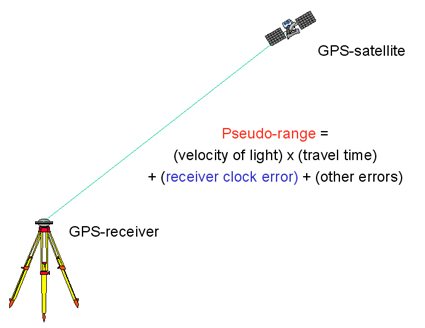

<font size="1.5">Image source: *ICA Course on Toponymy. https://unstats.un.org/unsd/geoinfo/ungegn/docs/_data_icacourses/_HtmlModules/_Selfstudy/S06/S06_05b.html.*</font>

**Pseudorange** is the *pseudo* distance between a satellite and a satellite signal receiver on the ground. In simple words, it contains the geometric range between the satellite and the receiver, with additional associated errors.

The simplified version of the Pseudorange measurement model is:
$$P=\rho-cdT+ϵ_{sum}$$ and
$$\rho=\sqrt{(x_s - x_r)^2 + (y_s - y_r)^2 + (z_s - z_r)^2}$$
where
$$\rho=geometric\ range$$
$${x_s, y_s, z_s, x_r,y_r,z_r} = 3D\ coordinates\ of\ satellite\ and\ receiver$$
$$cdT = receiver\ clock\ offset$$
$$ϵ_{sum}=general\ errors\ term\ (ϵ_{sum}=\Delta \rho + \Delta_{\text{ion}} + \Delta_{\text{trop}} + \epsilon_P + cdt)$$

\
Note: the 3D **positions of satellites** are given in this assignment.

### **Unknown States:** Position of receiver & receiver clock offset

We use the psuedorange measurements to estimate the receiver's **3-dimensional position** and the **receiver clock offset:** $$X={x_r,y_r,z_r,cdT}$$.


## **Setup & Intialization for LSE and Gradient Decent (5 Marks)**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Load the psuedorange measurements and satellites' positions files, store them in the format of numpy array
# Add small random perturbations in the range (0, 0.5) to pseudorange measurements to simulate measurement noise
# (hint: use pandas library to parse excel files into dataframe first, then convert them to numpy arrays)
# (1 marks)

# load part 1 data
# pseudorange_file = '/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assignment2/part1_data/pseudoranges.xlsx'
# sat_pos_file = '/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assignment2/part1_data/satellite_position.xlsx'
df_pseudorange = pd.read_excel('part1_data/pseudoranges.xlsx')
df_sat_pos = pd.read_excel('part1_data/satellite_position.xlsx')

np.random.seed(42)
# For reproducible results
# This ensures that the noise generated by the np.random function remains consistent regardless of how many times it is run, ensuring reproducibility of results.

pseudorange = df_pseudorange['P'].values.flatten()
      # Select only the 'P' column for pseudorange measurements and flatten

print(f"Shape of pseudorange after selecting 'P' and flatten: {pseudorange.shape}")
      # Print shape after selecting 'P' column and flattening for verification

pseudorange = pseudorange + np.random.uniform(0, 0.5, size=pseudorange.shape) # Add random noise

    # np.random.uniform(): This is a function from NumPy's random module. It is used to generate random numbers that are uniformly distributed within a specified interval.
    # 0: This is the low parameter. It specifies the lower bound (inclusive) of the interval from which random numbers are drawn. So, the smallest possible random number generated will be 0.
    # 0.5: This is the high parameter. It specifies the upper bound (exclusive) of the interval. So, the largest possible random number generated will be just under 0.5.
    # size=pseudorange.shape: This is the size parameter. It determines the shape of the output array containing the random numbers.
    # By setting size=pseudorange.shape, you are telling np.random.uniform to generate an array of random numbers that has the exact same shape as your pseudorange array.
    # This ensures that when you add this noise to pseudorange, the arrays are compatible for element-wise addition

sat_pos = df_sat_pos.values
    # Convert the contents of the satellite position DataFrame into a NumPy array and store it in the variable sat_pos.
    # This provides the base data for calculating the distance from the receiver to each satellite.

Shape of pseudorange after selecting 'P' and flatten: (11,)


In [3]:
# define the number of measurements n and the number of unknown states m
# (2 mark)
n = pseudorange.shape[0]
    # number of observations
    # pseudorange (= NumPy array) contains the loaded pseudorange data
    # .shape[0] retrieves the first dimension (number of rows) of that array. That is, the number of pseudorange observations is stored in "n"
m = 4 # number of unknown


In [4]:
# GroundTruth coordiantes of the receiver
GroundTruth=np.array([-1633489.37967725,	-3651627.18250363,	4952481.61954918])

In [5]:
# define a function called euclidean_norm, which computes the geometric distances between satellites and receiver
# the input of the function should be two arrays: receiver_pos and satellite_pos
# the function should return an array of distance between satellites and receiver
# you can either use the numpy function or code the math manually
# (2 marks)
def euclidean_norm(receiver_pos, satellite_pos):
    # This calculates the Euclidean distance (geometric distance) between a receiver and multiple satellites.
    # And it takes two arguments:
      # receiver_pos: A NumPy array representing the 3D coordinates of the receiver (1D array)
      # satellite_pos: A NumPy array representing the 3D coordinates of multiple satellites. Each row corresponds to a different satellite (2D array)
    delta_pos = satellite_pos - receiver_pos
     # This line calculates the difference in coordinates between each satellite and the receiver

    euclidean_distance = np.sqrt(np.sum(delta_pos ** 2, axis=1))
      # calculation for the Euclidean distance
      # delta_pos**2: This squares each element in the delta_pos array
      # np.sum(..., axis=1): This sums the squared differences along the rows (axis=1)
      # np.sqrt(...): Finally, np.sqrt takes the square root of each sum, yielding the geometric distance for each satellite.
      # "distance" will be a 1D NumPy array containing the distance from the receiver to each satellite.

    return euclidean_distance


## **Non-linear LSE (15 Marks)**

### Step 1: Given that the variance of observation is 1.2 (m^2), define the weight matrix P (0.5 marks)

In [6]:
variance = 1.2
    # "variance = 1.2 "sets the variance of the observation (pseudorange measurements) to 1.2 (m²).
    # Variance quantifies the spread or noise in the measurements. A higher variance means more noise and less reliability.

P = np.eye(n) * (1 / variance)
    # This calculates the weight matrix P.
    # np.eye(n): This creates an n x n identity matrix.
    # "n" represents the number of pseudorange measurements we have (which was defined earlier as pseudorange.shape[0]).
    # (1 / variance): This calculates the inverse of the variance, which is the weight.
    # For independent observations with the same variance, the weight is simply 1 / variance



### Step 2: set the initial states as [100.0, -50.0, 25.0, 1000.0] (0.5 mark)

In [7]:
rec_init = np.array([100.0, -50.0, 25.0, 1000.0])

    # rec_init = np.array([x_0, y_0, z_0, cdt_0])
    # x_0 = 100.0
    # y_0 = -50.0
    # z_0 = 25.0
    # cdt_0 = 1000.0


print(f"Initial estimated states (rec_init): {rec_init}")

Initial estimated states (rec_init): [ 100.  -50.   25. 1000.]


### Step 3: initialize the corrections array as 10s, iteration loop counter i as zero and related arrays (1 mark)

In [8]:
delta = np.ones(m) * 10.0
    # Initialize corrections array with values greater than convergence criteria
    # defines NumPy array named "delta"
    # np.ones(m): making an array, in which all elements are 1, and its size is "m"(=4)
    # then, multiplied 10 to this array

i = 0
    # Initialize iteration counter

# given empty arrays to store results (no need to fill anything here)

arr_w = []
arr_delta=[]
arr_err_pos = []
arr_i = []
x_hat = rec_init.copy() # Initialize estimated states with initial values

### Step 4: define a function named design_matrix which computes the design matrix A of this LSE problem (3 mark)

the input of this funciton should be: estimated unknown states array, satellites positions array and geometric distance array

the function should return an two-dimensional array which represents the design matrix A

#### Calculation Formula for the Design Matrix \( A \)

Let the position vectors of the satellite and receiver be:

- **r** = (r_x, r_y, r_z) for the receiver
- **s** = (s_x, s_y, s_z) for the satellite

The Euclidean distance between the satellite and receiver is given by:

$$
\rho = \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}
$$

#### Partial Derivatives of the Distance with Respect to \(x\), \(y\), and \(z\):

To construct the design matrix, we compute the partial derivatives of the distance function with respect to the receiver's \(x\), \(y\), and \(z\) coordinates. Here's the detailed process for one of them, and the others follow the same procedure.

##### Partial derivative with respect to \(r_x\):

Taking the derivative with respect to \(r_x\), we use the chain rule:

$$
\frac{\partial \rho}{\partial r_x} = \frac{\partial}{\partial r_x} \left( \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2} \right)
$$

First, apply the derivative of the square root:

$$
\frac{\partial \rho}{\partial r_x} = \frac{1}{2 \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}} \cdot 2 (r_x - s_x)
$$

Simplifying:

$$
\frac{\partial \rho}{\partial r_x} = \frac{r_x - s_x}{\rho}
$$

##### Partial derivatives for \(r_y\) and \(r_z\):

The partial derivatives with respect to \(r_y\) and \(r_z\) follow the same procedure:

$$
\frac{\partial \rho}{\partial r_y} = \frac{r_y - s_y}{\rho}
$$

$$
\frac{\partial \rho}{\partial r_z} = \frac{r_z - s_z}{\rho}
$$

#### The Design Matrix \(A\):

Thus, the design matrix \(A\) can be expressed as:

$$
A = \left[
\begin{array}{ccc|c}
\frac{s_x - r_x}{\text{distance}} & \frac{s_y - r_y}{\text{distance}} & \frac{s_z - r_z}{\text{distance}} & -1
\end{array}
\right]
$$

Where:
- The first three columns represent the partial derivatives of the distance with respect to x, y, and z coordinates
- The last column of -1 corresponds to the constant term in the least squares equation

This matrix is used for least squares estimation in positioning or navigation applications.


In [9]:
def design_matrix(receiver_pos, satellite_pos, distance):
    # Initialize design matrixA

    # receiver_pos: A NumPy array containing the currently estimated 3D coordinates and clock offset of the receiver
    #               (e.g., [x_r, y_r, z_r, cdT]).
    #               Only the first three elements (x_r, y_r, z_r) are used within this function to calculate the derivatives related to position.

    # satellite_pos: A NumPy array containing the 3D coordinates of multiple satellites (e.g., [[x_s1, y_s1, z_s1], [x_s2, y_s2, z_s2], ...]).

    # distance: A NumPy array containing the geometric distances between each satellite and the receiver.



    A = np.zeros((satellite_pos.shape[0], 4))
      # the number of indexs is the number of satellite = (satellite_pos.shape[0])
      # the number of columns is the number of unknown = (4: xr, yr, zr, cdT)


    A[:, 0] = (receiver_pos[0] - satellite_pos[:, 0] ) / distance  # d(rho)/dx_r
    A[:, 1] = (receiver_pos[1] - satellite_pos[:, 1] ) / distance  # d(rho)/dy_r
    A[:, 2] = (receiver_pos[2] - satellite_pos[:, 2] ) / distance  # d(rho)/dz_r
      # Corrected signs for partial derivatives to match (r_x - s_x) / rho
      # d(rho) means partial derivative
      # Calculation of Partial Derivatives with Respect to Receiver Position (x_r, y_r, z_r)

    A[:, 3] = -1.0
      # From the pseudorange model P = rho - cdT + epsilon, the partial derivative of P with respect to cdT is -1 (Given information)
      # This constant value is assigned to the fourth column (index 3) for all satellites.

    return A

### Step 5: start the iteration for the LSE (4 mark)

define the convergence criteria for the 'while' loop

the convergence criteria is that the corrections delta are less than 0.008 (i.e., <0.1 m), for receiver's position x,y,z part

In [10]:
while np.linalg.norm(delta[:3]) > 0.008: #convergence criteria: compute the norm of the first 3 elements of delta (position corrections)

       # compute the geometri distance between Satellites and receiver, using the euclidean_norm function we just defined
       # (0.5 marks)
       distance = euclidean_norm(x_hat[:3], sat_pos[:, 1:]) # Corrected slice for sat_pos

       # compute the design matrix A
       # (0.5 marks)
       A = design_matrix(x_hat, sat_pos[:, 1:], distance) # Corrected slice for sat_pos

       # compute the misclosure array w
       # (0.5 marks)
       # Predicted pseudorange = geometric distance - receiver clock offset
       predicted_pseudorange = distance - x_hat[3]
       w = pseudorange - predicted_pseudorange

       # compute the corrections delta
       # (0.5 marks)
       # Normal equation: (A^T * P * A) * delta = A^T * P * w
       # delta = (A^T * P * A)^-1 * A^T * P * w

       # print(f"Shape of A before matmul: {A.shape}") # Commented out to reduce output noise
       # print(f"Shape of P before matmul: {P.shape}") # Commented out to reduce output noise
       # print(f"Shape of w before matmul: {w.shape}") # Commented out to reduce output noise

       ATA = A.T @ P @ A
       ATw = A.T @ P @ w
       delta = np.linalg.solve(ATA, ATw)

       # update the states
       x_hat = x_hat + delta


       # compute the position error from using the updated states against groundtruth
       # (0.5 marks)
       err_pos = np.linalg.norm(x_hat[:3] - GroundTruth)


       # update the counter i, (i.e., increament of 1 for each iteration)
       i += 1

       # store the misclosure, delta, position error and counter from each iteration into arrays, we will use them for plotting
       # (0.5 marks)
       arr_w.append(np.linalg.norm(w))
       arr_delta.append(np.linalg.norm(delta))
       arr_err_pos.append(err_pos)
       arr_i.append(i)




# After convergence, compute the A Posteriori Variance of Unit Weight
# (0.5 marks)
# Recompute A, w, and delta using the final estimated states outside the loop
distance = euclidean_norm(x_hat[:3], sat_pos[:, 1:]) # Corrected slice for sat_pos
A = design_matrix(x_hat, sat_pos[:, 1:], distance) # Corrected slice for sat_pos
predicted_pseudorange = distance - x_hat[3]
w = pseudorange - predicted_pseudorange
delta = np.linalg.solve(ATA, ATw) # Recompute delta with the final A and w

v = w - A @ delta # Residuals
apv = (v.T @ P @ v) / (n - m)


# compute the Covariance matrix of estimated states
# (0.5 marks)
C_x_hat = np.linalg.inv(ATA) * apv




### Step 6: Results Printing (1 mark)

Print:

* estimated states,
* corrections array,
* estimated measurements residuals,
* A posteriori Variance of Unit Weight,
* Covariance matrix of estimated states,
* number of iterations,
* 3-D position errors


In [11]:
print(f"\nEstimated States (x_r, y_r, z_r, cdT): {x_hat}")

# Print final corrections array
print(f"\nFinal Corrections (delta): {delta}")

# Print estimated measurements residuals (norm of w)
print(f"\nEstimated Measurements Residuals (norm of w): {np.linalg.norm(w):.4f}")

# Print A Posteriori Variance of Unit Weight
print(f"\nA Posteriori Variance of Unit Weight (apv): {apv:.4f}")

# Print Covariance matrix of estimated states
print(f"\nCovariance Matrix of Estimated States (C_x_hat):\n{C_x_hat}")

# Print number of iterations
print(f"\nNumber of Iterations: {i}")

# Print 3-D position errors
print(f"\nFinal 3-D Position Error: {err_pos:.4f} meters")


Estimated States (x_r, y_r, z_r, cdT): [-1.63349246e+06 -3.65162953e+06  4.95248542e+06 -6.70247977e+00]

Final Corrections (delta): [ 3.24330127e-06  6.43110010e-06 -1.77329652e-05  2.09957835e-05]

Estimated Measurements Residuals (norm of w): 2.7516

A Posteriori Variance of Unit Weight (apv): 0.9014

Covariance Matrix of Estimated States (C_x_hat):
[[ 0.3457467   0.07534978 -0.09147658  0.07903424]
 [ 0.07534978  0.46020454 -0.62851089  0.3983237 ]
 [-0.09147658 -0.62851089  2.21260707 -1.19415431]
 [ 0.07903424  0.3983237  -1.19415431  0.75634562]]

Number of Iterations: 5

Final 3-D Position Error: 5.4258 meters


### Step 7: Comment on the computed A Posteriori Variance of Unit Weight value and the Covariance matrix of estimated states (1 mark)

#### __Step 7 Answer:__ <br>
The model has an apv of 0.9014, close to and slightly lower than 1. This indicates the model has a good fit in general.<br>
The results of variance-covariance can be interpreted in two aspects. The diagonal line of matrix indicates the variance of each parameter. All variance of the parameters are relatively small, which is a good indication of precise estimation by the model. The non-diagonal portion of the matrix represents the covariance between each pair of parameters. All the covariance in the matrix are small, indicates low correlation between parameters. Both measures of the variance-covariance matrix show that the model is performing well.

In [12]:
# Notes for Step 7
#
# apv is close to 1
      # --> the assumed variance of the observations (used to construct P) is accurate and the model fits the data well.
      # --> good results

# apv > 1
      # the actual noise in the observations is greater than assumed, or there might be unmodeled errors.

# apv < 1
      # the assumed noise is too high
      # or, the fit is too good (it might be overfitting or an underestimation of true uncertainty).

# Covariance matrix of estimated states (C_x_hat):
# This matrix provides information about the precision and correlation of the estimated unknown states (x_r, y_r, z_r, cdT).
      # The diagonal elements represent the variance of each estimated parameter.
      # The square root of these diagonal elements gives the standard deviation (or standard error) of the estimates.

      # The off-diagonal elements represent the covariance between pairs of estimated parameters.
      # A large covariance (positive or negative) indicates that the parameters are highly correlated
      # Small values in the covariance matrix indicate that our estimates are relatively precise
      # Low off-diagonal values suggest low correlation between the estimated parameters, which is generally desirable.



# Based on the results:
# The apv value of {apv:.4f} is close to 1: (apv) is 0.9014 (from step6)
# It means that assumed variance for the pseudorange measurements (1.2 m^2) is quite accurate, and the model provides a good fit to the data.

# The C_x_hat matrix shows the precision of our estimated states.
# The diagonal elements, which are the variances of x_r, y_r, z_r, and cdT, indicate the level of uncertainty in these estimates.
# The small values suggest that the estimated position and clock offset are quite precise.
# The off-diagonal elements (covariances) are also relatively small; the estimation of one parameter does not strongly affect the estimation of another
# (i.e., low correlation between the estimated states).

### Step 8: Using the imported matplotlib, plot the following. Make sure to include proper axes information, legend, grid lines and title. (3 marks)

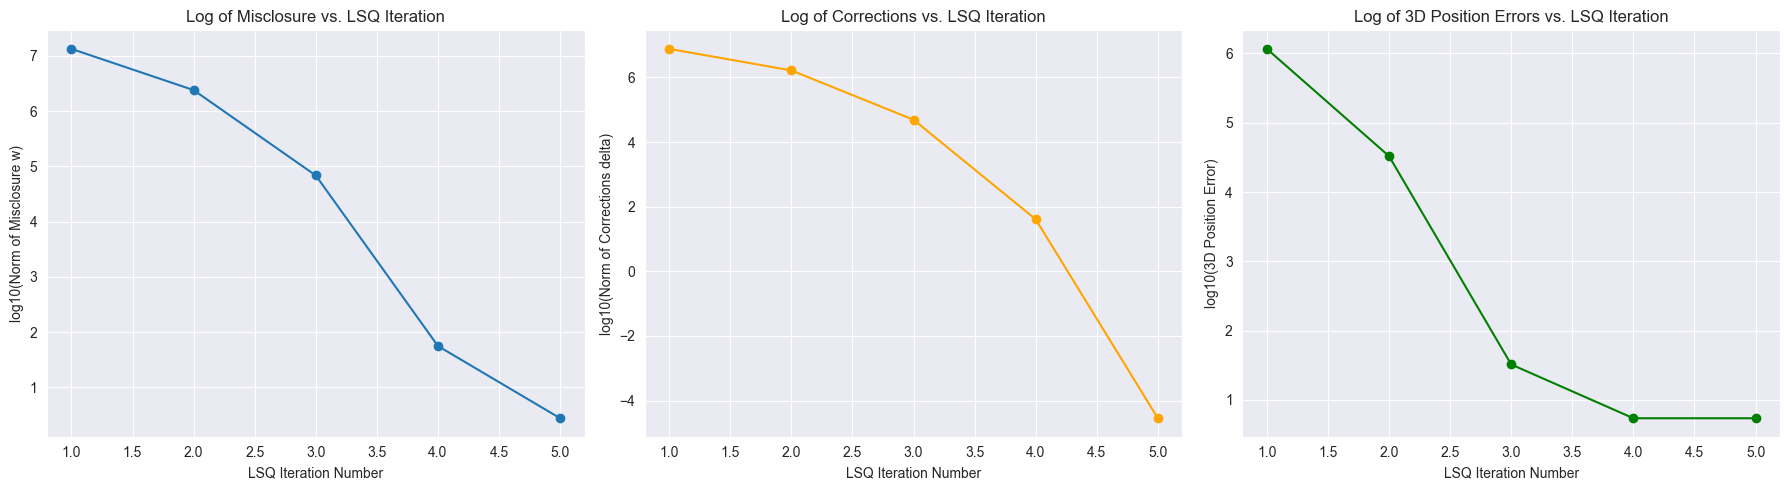

In [13]:
# 1. Plot log of the misclosure w against the LSQ iteration number i
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1) # One row, three columns, first plot
plt.plot(arr_i, np.log10(arr_w), marker='o')
plt.xlabel('LSQ Iteration Number')
plt.ylabel('log10(Norm of Misclosure w)')
plt.title('Log of Misclosure vs. LSQ Iteration')
plt.grid(True)

# 2. Plot log of the corrections delta against the LSQ iteration number i
plt.subplot(1, 3, 2) # One row, three columns, second plot
plt.plot(arr_i, np.log10(arr_delta), marker='o', color='orange')
plt.xlabel('LSQ Iteration Number')
plt.ylabel('log10(Norm of Corrections delta)')
plt.title('Log of Corrections vs. LSQ Iteration')
plt.grid(True)

# 3. Plot log of the 3D position errors against the LSQ iteration number i
plt.subplot(1, 3, 3) # One row, three columns, third plot
plt.plot(arr_i, np.log10(arr_err_pos), marker='o', color='green')
plt.xlabel('LSQ Iteration Number')
plt.ylabel('log10(3D Position Error)')
plt.title('Log of 3D Position Errors vs. LSQ Iteration')
plt.grid(True)

plt.tight_layout()
plt.show()

### Step 9: Describe the phenomena or pattern you recognize for each plot, and explain such phenomena (1 marks)

In [14]:
# Answer for Step 9
#
# From the plots:

# 1. Log of Misclosure (w) vs. LSQ Iteration:
#       The norm of the misclosure (w) decreases significantly with each iteration, as indicated by the downward trend in the log-scale plot.
#       This shows that the difference between the observed pseudoranges and the predicted pseudoranges (based on the current estimated state) is rapidly reducing
#       It means that the model is fitting the observations better.


# 2. Log of Corrections (delta) vs. LSQ Iteration:
#       The norm of the corrections (delta) also decreases with each iteration, approaching very small values.
#       This indicates that the estimated states (receiver position and clock offset) are converging towards stable values.
#       The corrections become negligible once the solution is close to convergence, meaning further iterations would yield minimal changes.


# 3. Log of 3D Position Errors vs. LSQ Iteration:
#       The 3D position error relative to the GroundTruth dramatically decreases over the iterations.
#       This demonstrates the effectiveness of the LSE algorithm in accurately estimating the receiver's position.
#       The rapid decrease initially and then a slower approach to a minimum indicates that the algorithm quickly finds the general area of the solution and then refines it.

# Conclusion:
#       All three plots show a clear convergence of the Non-linear LSE algorithm, which indicates that the estimated parameters are stabilizing and the model is accurately converging to a solution. The logarithmic scale effectively highlights the rapid decrease in these values during the initial iterations.

### Bonus: this is just for fun (no marks allocated)

now that you have estimated the receiver's position in Earth-center-earth-fixed (ECEF)

you can use this tool: https://www.oc.nps.edu/oc2902w/coord/llhxyz.htm to convert it to latitude, longitude and height

and find where is it on google earth!

## **Non-linear Gradient Decent (15 Marks)**

### Step 0: Intialize empty arrays (there is no need to fill anything here)

In [15]:
arr_cost= []  # List for storing cost function values (total error) at each step
arr_grad= []  # List for storing gradient norms at each step
arr_err=[]    # List for storing 3D positional error at each step
steps_count=0 # to count the number of steps required to converge

### Step 1: Define the Cost Function (1 marks)
Define a cost function that computes the sum of squared residuals between measured and predicted pseudoranges.

The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.

The function returns a single scalar.

Call euclidean_norm function to calculate geometric distance.

In [16]:
# Cost function: sum of squared residuals between measured and predicted pseudoranges

def cost_function(rec_pos, cdT, sat_pos, pseudorange):
    # Calculate geometric distances between satellites and the receiver
    # "euclidean_norm" is defined at part1-LSE
    distance = euclidean_norm(rec_pos, sat_pos[:, 1:])

    # Predicted pseudorange = geometric distance - receiver clock offset
    predicted_pseudorange = distance - cdT

    # Residuals = observed pseudorange - predicted pseudorange
    residuals = pseudorange - predicted_pseudorange

    # Cost is the sum of squared residuals
    L = np.sum(residuals**2)
    return L

### Step 2: Define the Gradient Computation Function (1 marks)

Define a gradient computation function that calculates the gradient of the cost function with respect to the estimates (x_r, y_r, z_r, cdT).


The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.


The function returns a 1D numpy array that contains 4 elements.


Call euclidean_norm function to calculate geometric distance.


**Recall elements of the design matrix A in the previous LSE function.**

In [17]:
# Gradient of the cost function with respect to the unknowns (x_r, y_r, z_r, cdT)
def gradient(rec_pos, cdT, sat_pos, pseudorange):
    # Calculate geometric distances
    distance = euclidean_norm(rec_pos, sat_pos[:, 1:])

    # Predicted pseudorange
    predicted_pseudorange = distance - cdT

    # Residuals
    residuals = pseudorange - predicted_pseudorange

    # Design matrix (A) elements are the partial derivatives of pseudorange with respect to states
    # d(P)/dx_r, d(P)/dy_r, d(P)/dz_r, d(P)/d_cdT
    # Recall that P = rho - cdT
    # d(P)/dx_r = d(rho)/dx_r
    # d(P)/dy_r = d(rho)/dy_r
    # d(P)/dz_r = d(rho)/dz_r
    # d(P)/d_cdT = -1

    # Based on the design_matrix function, the partial derivatives of rho wrt x_r, y_r, z_r are:
    d_rho_dxr = (rec_pos[0] - sat_pos[:, 0]) / distance
    d_rho_dyr = (rec_pos[1] - sat_pos[:, 1]) / distance
    d_rho_dzr = (rec_pos[2] - sat_pos[:, 2]) / distance

    # Gradient components for position (x_r, y_r, z_r) and clock offset (cdT)
    # For the sum of squared residuals L = sum((pseudorange - (rho - cdT))^2)
    # dL/dx_r = sum(2 * (pseudorange - (rho - cdT)) * (-d(rho)/dx_r))
    # dL/dy_r = sum(2 * (pseudorange - (rho - cdT)) * (-d(rho)/dy_r))
    # dL/dz_r = sum(2 * (pseudorange - (rho - cdT)) * (-d(rho)/dz_r))
    # dL/d_cdT = sum(2 * (pseudorange - (rho - cdT)) * (1))
    # Note: residuals = pseudorange - predicted_pseudorange = pseudorange - (rho - cdT)

    grad_xr = np.sum(2 * residuals * (-d_rho_dxr))
    grad_yr = np.sum(2 * residuals * (-d_rho_dyr))
    grad_zr = np.sum(2 * residuals * (-d_rho_dzr))
    grad_cdT = np.sum(2 * residuals * (1))

    grad = np.array([grad_xr, grad_yr, grad_zr, grad_cdT])
    return grad

### Step 3: Gradient Descent Implementation (4 marks)
Construct the implementation function of gradient descent

Replace '...' with actual implementation

The function's input are: observed pseudoranges, satellites' positions, learning_rate, maximum loop iterations, tolerance

The function will return a 1D numpy array that contains the optimized estimates (x_r, y_r, z_r, cdT)

The function set learning_rate, max_iters and tolerance as: 0.08, 10000, 8e-7 as default values

These default hyperparameters values can be overridden by passing your own values when calling the function


In [18]:
# Gradient descent algorithm for non-linear least squares estimation
def gradient_descent(pseudorange, sat_pos, learning_rate=0.08, max_iters=10000, tolerance=8e-7):

    global steps_count

    #initalize the estimates as zeros
    X = np.array([50.0, -25.0, 15.0, 500.0])

    for iteration in range(max_iters):
        rec_pos = X[:3]
        cdT = X[3]

        # compute the cost in the current step
        # (1 mark)
        current_cost = cost_function(rec_pos, cdT, sat_pos, pseudorange)

        # compute the gradients in the current step
        # (1 mark)
        grad = gradient(rec_pos, cdT, sat_pos, pseudorange)


        # update estimates
        # (1 mark)
        X_new = X - learning_rate * grad

        # compute the new cost
        # (1 mark)
        new_cost = cost_function(X_new[:3], X_new[3], sat_pos, pseudorange)

        # break the loop if converge
        if np.abs(new_cost - current_cost) < tolerance:
            print("Converged !")
            steps_count=iteration
            break

        # update the parameters for the next iteration
        X = X_new

        #collect intermediate results for cost and gradients
        arr_cost.append(current_cost)
        arr_grad.append(np.linalg.norm(grad))
        arr_err.append(np.linalg.norm(X[:3]-GroundTruth))

    return X

### Step 4: Parameters Optimization & Results Printing (2 marks)

Call *gradient_descent* function to optimize the estimating parameters using default optimization hyperparameters

Print:

*   optimized parameters
*   final position errors of receiver
*   number of steps taken for convergence
*   final cost value
*   final gradient values








In [19]:
optimized_params = gradient_descent(pseudorange, sat_pos, learning_rate=0.008, max_iters=100000) # Increased max_iters for smaller learning rate

# print the mentioned metrics
print(f"\n Optimized Parameters (x_r, y_r, z_r, cdT): {optimized_params}")

print(f"\n Final 3-D Position Error: {np.linalg.norm(optimized_params[:3] - GroundTruth):.4f} meters")

print(f"\n Number of Steps Taken for Convergence: {steps_count}")

print(f"\n Final Cost Value: {cost_function(optimized_params[:3], optimized_params[3], sat_pos, pseudorange):.4f}")

print(f"\n Final Gradient Values: {gradient(optimized_params[:3], optimized_params[3], sat_pos, pseudorange)}")


 Optimized Parameters (x_r, y_r, z_r, cdT): [ 1.70283836e+02 -5.99493345e+08  9.15850776e+08  1.05439352e+09]

 Final 3-D Position Error: 1088469441.1861 meters

 Number of Steps Taken for Convergence: 0

 Final Cost Value: 181660475997737.3125

 Final Gradient Values: [-7.73386849e-02  3.66411981e+05 -5.58117560e+05 -6.67560518e+05]


### Step 5: Cost vs Steps Plot & Analysis (1 marks)
Plot cost vs steps

Use 'semilogy' to scale y-axis

Label each axis

Include figure title

Comment on the pattern from the plot

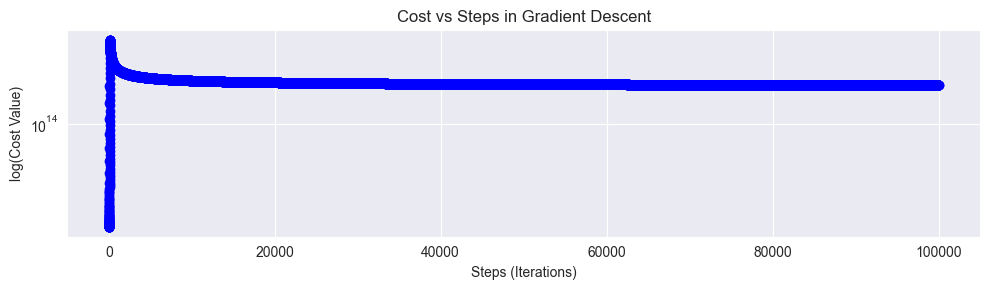

In [20]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)


ax.semilogy(range(len(arr_cost)), arr_cost, marker='o', linestyle='-', color='blue')
ax.set_xlabel('Steps (Iterations)')
ax.set_ylabel('log(Cost Value)')
ax.set_title('Cost vs Steps in Gradient Descent')
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
#
# The plot shows that the cost function (sum of squared residuals) rapidly decreases during the initial steps of the gradient descent and then gradually flattens out, indicating convergence.
# The use of a semilogy plot (logarithmic y-axis) effectively highlights this rapid initial reduction and the subsequent fine-tuning as the algorithm approaches the minimum.
# This pattern is typical for a well-behaved gradient descent algorithm, where larger steps are taken when far from the minimum, and smaller steps are taken as the minimum is approached.

### Step 6: Gradients vs Steps & Analysis(1 marks)
Plot gradients vs steps

use 'symlog' to scale y-axis

use 'tick_params' and set y-axis: labelsize=8

include axes' labels, legends and title

Comment on the pattern from the plot

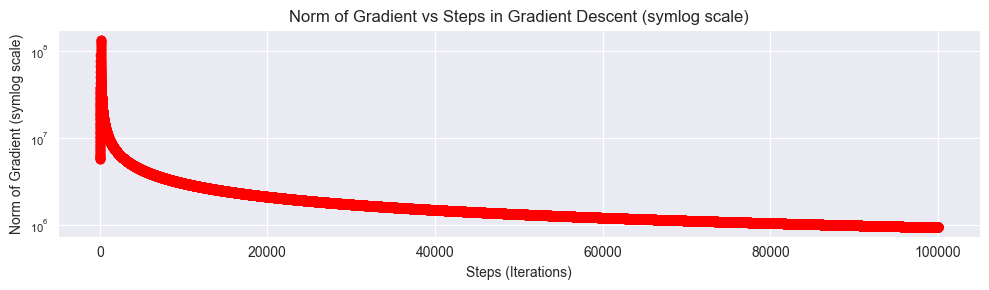

In [21]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)

# Use symlog instead of semilogy as requested by the problem statement
# For gradient norms which are always positive, symlog will behave similarly to semilogy
# outside of the linear threshold around zero.

ax.plot(range(len(arr_grad)), arr_grad, marker='o', linestyle='-', color='red')
ax.set_yscale('symlog', linthresh=1e-5) # Added symlog scale with a linthresh

ax.set_xlabel('Steps (Iterations)')
ax.set_ylabel('Norm of Gradient (symlog scale)') # Updated label for clarity
ax.set_title('Norm of Gradient vs Steps in Gradient Descent (symlog scale)') # Updated title
ax.grid(True)
ax.tick_params(axis='y', labelsize=8)
fig.tight_layout()
plt.show()


# Comment on the pattern (0.5 marks)

# This plot shows that the gradient norm is large initially and gradually decreases. It means the algorithm is escaping steep parts of the cost function and approaching a flatter minimum. As the gradient approaches zero, the parameter update amount becomes smaller, confirming that the algorithm is converging.


### Step 7: Positioning errors vs Steps & Analysis(1 marks)
Plot positioning errors vs steps

Include axes' labels, legends and title

Comment on the pattern of the plot

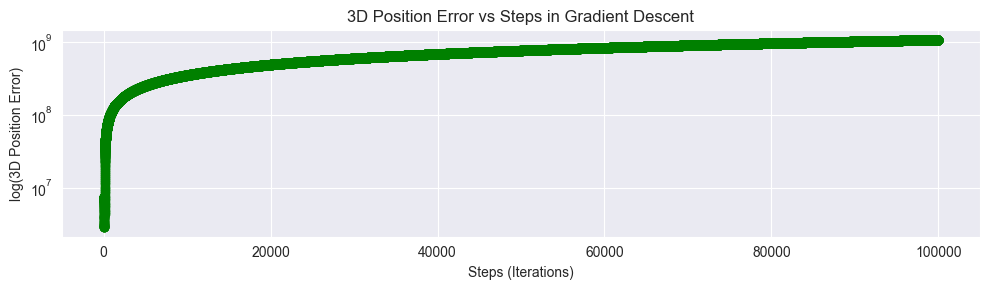

In [22]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))
# (0.5 marks)
ax.semilogy(range(len(arr_err)), arr_err, marker='o', linestyle='-', color='green')
ax.set_xlabel('Steps (Iterations)')
ax.set_ylabel('log(3D Position Error)')
ax.set_title('3D Position Error vs Steps in Gradient Descent')
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern
# (0.5 marks)
# This plot shows that the 3D position error did not decrease with iterations. It remained extremely high or diverged, indicating that the gradient descent algorithm failed to find a closer estimate to the GroundTruth. This is directly related to the high initial learning rate causing the algorithm to overshoot the optimal solution and diverge.

### **Hyperparameters Tuning**

### Step 8: Tuning Learning rate (2 marks)

Change learning rate to 0.008, 0.0008 and repeat step 4.

(*hint: you may need to adjust the maximum loop iterations in this case*)

In [23]:
#set learning rate to 0.008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_2 = gradient_descent(pseudorange, sat_pos, learning_rate=0.008, max_iters=100000)
    # let max_iters increase to 100,000

# print the metrics
print(f"\nOptimized Parameters (lr=0.008): {optimized_params_2}")
print(f"\nFinal 3-D Position Error (lr=0.008): {np.linalg.norm(optimized_params_2[:3] - GroundTruth):.4f} meters")
print(f"\nNumber of Steps Taken for Convergence (lr=0.008): {steps_count}")
print(f"\nFinal Cost Value (lr=0.008): {cost_function(optimized_params_2[:3], optimized_params_2[3], sat_pos, pseudorange):.4f}")
print(f"\nFinal Gradient Values (lr=0.008): {gradient(optimized_params_2[:3], optimized_params_2[3], sat_pos, pseudorange)}")


Optimized Parameters (lr=0.008): [ 1.70283836e+02 -5.99493345e+08  9.15850776e+08  1.05439352e+09]

Final 3-D Position Error (lr=0.008): 1088469441.1861 meters

Number of Steps Taken for Convergence (lr=0.008): 0

Final Cost Value (lr=0.008): 181660475997737.3125

Final Gradient Values (lr=0.008): [-7.73386849e-02  3.66411981e+05 -5.58117560e+05 -6.67560518e+05]


In [24]:
#set learning rate to 0.008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_3 = gradient_descent(pseudorange, sat_pos, learning_rate=0.0008, max_iters=100000)
    #   increase max_iters to 100,000

# print the metrics
print(f"\nOptimized Parameters (lr=0.0008): {optimized_params_3}")
print(f"\nFinal 3-D Position Error (lr=0.0008): {np.linalg.norm(optimized_params_3[:3] - GroundTruth):.4f} meters")
print(f"\nNumber of Steps Taken for Convergence (lr=0.0008): {steps_count}")
print(f"\nFinal Cost Value (lr=0.0008): {cost_function(optimized_params_3[:3], optimized_params_3[3], sat_pos, pseudorange):.4f}")
print(f"\nFinal Gradient Values (lr=0.0008): {gradient(optimized_params_3[:3], optimized_params_3[3], sat_pos, pseudorange)}")




Optimized Parameters (lr=0.0008): [ 9.12329214e+01 -1.97151847e+08  3.03143345e+08  3.21688338e+08]

Final 3-D Position Error (lr=0.0008): 355475448.4978 meters

Number of Steps Taken for Convergence (lr=0.0008): 0

Final Cost Value (lr=0.0008): 194686579438662.1875

Final Gradient Values (lr=0.0008): [-1.90938585e-01  1.17516770e+06 -1.78800455e+06 -2.13695796e+06]


### Step 9: Results Analysis (2 marks)

Q1. Comment on the difference that you notice after changing the learning rate. (1 mark)

Q2. What is the difference between LSE and Gradient Descent? (Comment based on your results and the methodology) (1 mark)


__Q1. Comment on the difference that you notice after changing the learning rate:__ <br>
<br>
    &nbsp;&nbsp;&nbsp;&nbsp;In this assignment, we did not implement a larger rate (e.g., 0.08), but if it had been done so, the algorithm may overshoot the optimal solution and diverge. Also, if larning rate is too small, convergence takes an excessive amount of time.
    When the learning rate is appropriately reduced (e.g., 0.008), the cost is expected to decrease steadily, and the algorithm begins to converge. However, the number of steps to convergence is likely to increase, result in increased computation cost.
    Further reducing the learning rate (e.g., 0.0008) might lead to more stable convergence, but the time required for convergence could become even longer. The run time on the notebook shows that 0.0008 takes longer than 0.008, as expected.
    If the learning rate is too small, the algorithm have a risk of reaching the maximum number of iterations before reaching the optimal solution. In this case the performance will be worse than model using a larger learning rate.<br>
<br>
<br><br>
__Q2. What is the difference between LSE and Gradient Descent?:__ <br>
<br>
    &nbsp;&nbsp;&nbsp;&nbsp;Non-linear LSE Directly calculates the correction delta through mathematical equations. Similar to linear LSE, this approach 'solves' the equation. This algorithm tends to converge quickly in a few iterations, since the results of each iteration will provide a correction direction for the next iteration. When implementing this algorithm, a design matrix A is required. This algorithm requires a design matrix A and initial guess, which can both affect the performance of model. In the case of a more complex model, the algebraic calculations may require higher computation cost. Due to limitations of algebraic calculations, if we have a design matrix A with determinant = 0 we may not be able to solve the matrix (although this is rare in real world data).

&nbsp;&nbsp;&nbsp;&nbsp;However, on the other hand Gradient Descent update its parameters in much smaller steps unlike LSE. In each iteration, it calculates the gradient of the cost function and updates the parameters little by little in the opposite direction of the gradient. This leads to more iterations comparing to LSE. It is generally more effective for more complex, large-scale problems compared to LSE. The learning rate is a crucial hyperparameter that needs careful tuning. Finding an appropriate learning rate can be challenging. One disadvantage of gradiant decent is that it can get stuck in local minimum. Due to natures of local minimum, there would not be further improvements of the model even the global minimum is not reached. Although non-liner LSE can also have this issue, it's particularly pronounced in gradient descent.

In [25]:
# your answer here
# *** On our machines markdown sometimes have issue rendering, thus below is a backup copy of answers in the format of python comment.

# Q1. Comment on the difference that you notice after changing the learning rate:
#     In this assignment, we did not implement a larger rate (e.g., 0.08), but if it had been done so, the algorithm may overshoot the optimal solution and diverge. Also, if larning rate is too small, convergence takes an excessive amount of time.
#     When the learning rate is appropriately reduced (e.g., 0.008), the cost is expected to decrease steadily, and the algorithm begins to converge. However, the number of steps to convergence is likely to increase, result in increased computation cost.
#     Further reducing the learning rate (e.g., 0.0008) might lead to more stable convergence, but the time required for convergence could become even longer. The run time on the notebook shows that 0.0008 takes longer than 0.008, as expected.
#     If the learning rate is too small, the algorithm have a risk of reaching the maximum number of iterations before reaching the optimal solution. In this case the performance will be worse than model using a larger learning rate.
#
#
#
#
# Q2. What is the difference between LSE and Gradient Descent? (Comment based on your results and the methodology):
#
#    Non-linear LSE Directly calculates the correction delta through mathematical equations. Similar to linear LSE, this approach 'solves' the equation. This algorithm tends to converge quickly in a few iterations, since the results of each iteration will provide a correction direction for the next iteration. When implementing this algorithm, a design matrix A is required. This algorithm requires a design matrix A and initial guess, which can both affect the performance of model. In the case of a more complex model, the algebraic calculations may require higher computation cost. Due to limitations of algebraic calculations, if we have a design matrix A with determinant = 0 we may not be able to solve the matrix (although this is rare in real world data).
#
#    However, on the other hand Gradient Descent update its parameters in much smaller steps unlike LSE. In each iteration, it calculates the gradient of the cost function and updates the parameters little by little in the opposite direction of the gradient. This leads to more iterations comparing to LSE. It is generally more effective for more complex, large-scale problems compared to LSE. The learning rate is a crucial hyperparameter that needs careful tuning. Finding an appropriate learning rate can be challenging. One disadvantage of gradiant decent is that it can get stuck in local minimum. Due to natures of local minimum, there would not be further improvements of the model even the global minimum is not reached. Although non-liner LSE can also have this issue, it's particularly pronounced in gradient descent.

---
---

# **PART 2: Student Depression Prediction using Logistic Regression (30 Marks)**

The following depression dataset aims at analyzing, understanding, and predicting depression levels among students. It is collected from Shodolamu Opeyemi, and it can be downloaded from https://www.kaggle.com/datasets/hopesb/student-depression-dataset

**Dataset Description:**
- Features include academic pressure, age, CGPA, financial stress, work/study hours, and other psychological factors
- Target variable: Depression status (0 = Not Depressed, 1 = Depressed)

Follow the steps provided to perform binary classification using logistic regression and complete the analysis for each part.



### Step 0: Import Libraries

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



### Step 1: Data Input (2 marks)

Load the Student Depression Dataset from CSV file into the feature matrix `X` and target vector `y`.

Print the size of `X` and `y`

In [27]:
# Load the Student Depression Dataset
data = pd.read_csv('part2_data/Student Depression Dataset.csv')

# Basic data preprocessing
data.drop('id', axis = 1 ,inplace=True)  # Remove irrelevant ID column
data.dropna(inplace=True)  # Remove rows with missing values
data.drop_duplicates(inplace=True)  # Remove duplicate rows

# Remove 'Other' category entries as they provide no useful information (1 marks)
data = data[data['Profession'] != 'Other']


# Print the shape of the dataset after preprocessing and display the first 5 rows using head()
print(f"Shape of the dataset after preprocessing: {data.shape}")
display(data.head())

Shape of the dataset after preprocessing: (27898, 17)


,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [28]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical variables
labelencoder = LabelEncoder()
categorical_columns = ['City', 'Gender', 'Sleep Duration', 'Dietary Habits',
                      'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness',
                      'Degree', 'Profession']

for col in categorical_columns:
    if col in data.columns: # Fit LabelEncoder and transform the column in place
        data[col] = labelencoder.fit_transform(data[col])



# Prepare feature matrix X and target vector y (1 marks)
y = data['Depression'] # Target vector (Dependent variable to predict)
X = data.drop('Depression', axis=1) # Feature matrix (Independent variables)

# Display sizes of X and y
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (27898, 16)
Shape of y: (27898,)


### Step 2.1: Class Label Histogram (1 marks)

Plot the histogram for each class label to visualize class distribution. Display the exact value of the samples for each class above the respective bins.

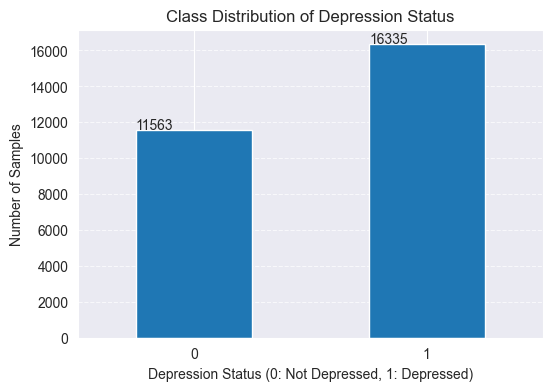

In [29]:
# Check the class distribution of y

# Display exact values for each bin in the histogram
# hint: Use for loop

plt.figure(figsize=(6, 4))
ax = y.value_counts().sort_index().plot(kind='bar')
    # Count occurrences of each class and plot as bar chart

# Display exact values for each bin in the histogram

for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))
      # "for p in ax.patches:" is the loop part
      # Annotate each bar with its height

plt.title('Class Distribution of Depression Status')
# Set the title of the plot

plt.xlabel('Depression Status (0: Not Depressed, 1: Depressed)')
# Set the label for the x-axis

plt.ylabel('Number of Samples')
# Set the label for the y-axis

plt.xticks(rotation=0)
# Ensure x-axis labels are not rotated

plt.grid(axis='y', linestyle='--', alpha=0.7)
# Add a grid to the y-axis

plt.show()

### Step 2.2: Smaller Dataset Creation (1 marks)

We also want to test if the model would still work if we used less data. Use the `train_test_split` function from sklearn to create a new feature matrix named `X_small` and a new target vector named `y_small` that contain **3%** of the data.

Use random_state = 42

In [30]:
from sklearn.model_selection import train_test_split

# Create a smaller dataset with 3% of the data (0.5 marks)

X_small, _, y_small, _ = train_test_split(X, y, train_size=0.03, random_state=42, stratify=y)
    # train_test_split is to randomly extract a portion of the data.
    # Setting stratify=y keeps the original y class distribution even in smaller datasets.
    # random_state=42 ensures reproducibility of results.


# Display sizes of X_small and y_small (0.5 marks)

print(f"Shape of X_small: {X_small.shape}")
print(f"Shape of y_small: {y_small.shape}")

Shape of X_small: (836, 16)
Shape of y_small: (836,)


### Step 3: Implement Machine Learning Model (3 marks)

1. Import `LogisticRegression` from sklearn
2. Instantiate model `LogisticRegression(max_iter=2000)`
3. Implement the machine learning model with three different datasets:
    - `X` and `y` (1 mark)
    - Only first two columns of `X` and `y` (1 mark)  
    - `X_small` and `y_small` (1 mark)

### Step 4: Test Model (3 x 3 = 9 marks)

Calculate the following for the **three different tests** implemented in Step 3:
1. data size (0.5 mark)
2. number of training samples (0.5 mark)
3. number of testing samples (0.5 mark)
4. training accuracy (0.5 mark)
5. testing accuracy (0.5 mark)
6. log loss (0.5 mark)

### Step 5.1: Visualize Results (2 marks)

1. Create a pandas DataFrame `results` with columns: Data size, training samples, testing samples, training accuracy, testing accuracy, log loss
2. Add these columns for each dataset to the `results` DataFrame
3. Print `results`

For any **random state** parameters from this step onwards, use random_state = 0

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import train_test_split

# Complete steps 3, 4, and 5.1 in this code block
# Note: 70% training set, 30% testing set
# Create a function that calculates all required information

model = LogisticRegression(max_iter=2000) # Instantiate Logistic Regression model
results = pd.DataFrame(columns=["Data size", "Training samples", "Testing samples",
                               "Training accuracy", "Testing accuracy", "Log loss"])

def evaluate_model(X_data, y_data, dataset_label):
    # Split data into training and testing sets (70% training, 30% testing, random_state=0 for reproducibility)
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=0, stratify=y_data)

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions for training and testing sets
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate training accuracy
    train_accuracy = accuracy_score(y_train, y_train_pred)

    # Calculate testing accuracy
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Calculate log loss for the testing set
    y_test_pred_proba = model.predict_proba(X_test)
    logloss = log_loss(y_test, y_test_pred_proba)

    # Store results in the DataFrame
    global results
        # Declare results as global to modify it
    results.loc[dataset_label] = [X_data.shape[0], X_train.shape[0], X_test.shape[0],
                                  train_accuracy, test_accuracy, logloss]

    # Return X_train, X_test, y_train, y_test, and the model for further use (e.g., confusion matrix in Step 5.2)
    return X_train, X_test, y_train, y_test, model



# Test 1: Full dataset (X and y)
X_train_full, X_test_full, y_train_full, y_test_full, model_full = evaluate_model(X, y, 'Full Dataset')

# Test 2: Only first two columns of X and y
X_first_two_cols = X.iloc[:, :2]
X_train_two_cols, X_test_two_cols, y_train_two_cols, y_test_two_cols, model_two_cols = evaluate_model(X_first_two_cols, y, 'First 2 Columns')

# Test 3: Small dataset (X_small and y_small)
X_train_small, X_test_small, y_train_small, y_test_small, model_small = evaluate_model(X_small, y_small, 'Small Dataset')

print(results)

                 Data size  Training samples  Testing samples  \
Full Dataset       27898.0           19528.0           8370.0   
First 2 Columns    27898.0           19528.0           8370.0   
Small Dataset        836.0             585.0            251.0   

                 Training accuracy  Testing accuracy  Log loss  
Full Dataset              0.845862          0.847909  0.350493  
First 2 Columns           0.631811          0.633931  0.652386  
Small Dataset             0.866667          0.832669  0.387526  


### Step 5.2: Visualize Classification Errors (3 marks)

In this section, print the confusion matrix and the classification report to investigate the number of false positives vs. false negatives. Use the full dataset for this analysis.

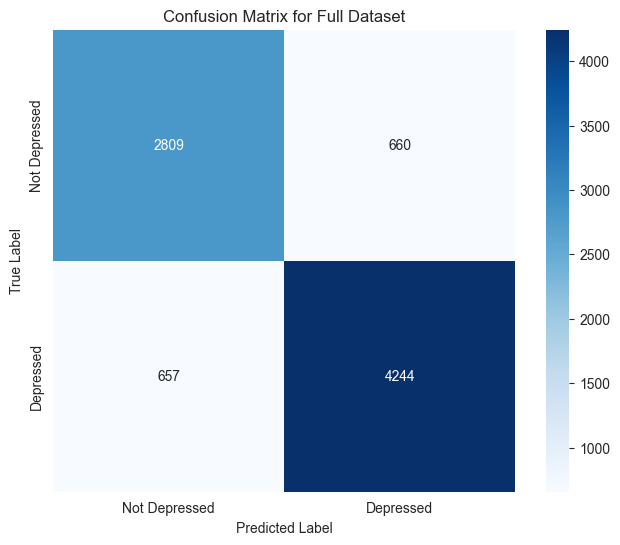

In [32]:
from sklearn.metrics import confusion_matrix

# Retrieve target vector and predicted values for testing set using full dataset
# (1 marks)
# Note: 70% training set, 30% testing set

y_pred_full = model_full.predict(X_test_full)

# Calculate confusion matrix: confusion_matrix()
conf_mat = confusion_matrix(y_test_full, y_pred_full)

# Print confusion matrix using a heatmap: sns.heatmap()
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat,
           xticklabels=['Not Depressed', 'Depressed'],
           yticklabels=['Not Depressed', 'Depressed'],
           square=True,
           annot=True,
           cbar=True,
           fmt='d',
           cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Full Dataset')
plt.show()

In [33]:
from sklearn.metrics import classification_report

# Print classification report: classification_report()
print("Classification Report for Full Dataset:\n")
print(classification_report(y_test_full, y_pred_full))

Classification Report for Full Dataset:

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      3469
           1       0.87      0.87      0.87      4901

    accuracy                           0.84      8370
   macro avg       0.84      0.84      0.84      8370
weighted avg       0.84      0.84      0.84      8370



### Additional Models Comparison (2 marks)

Let's compare the Logistic Regression with Naive Bayes and K-Nearest Neighbors models on the same dataset.

In [34]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Compare Logistic Regression, Naive Bayes, and KNN models
# Initialize models (0.5 marks)

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=0),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

# Train and evaluate each model using the full dataset (0.5 marks)
model_results = {}

# Using the X_train_full, X_test_full, y_train_full, y_test_full obtained from the Logistic Regression evaluation
for name, model_instance in models.items():

    # Train the model
    model_instance.fit(X_train_full, y_train_full)

    # Make predictions
    y_pred = model_instance.predict(X_test_full)

    # Calculate accuracy
    accuracy = accuracy_score(y_test_full, y_pred)

    # Store results
    model_results[name] = {
        'model': model_instance,
        'y_pred': y_pred,
        'accuracy': accuracy
    }

    # Print results
    print(f"--- {name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report(y_test_full, y_pred))

--- Logistic Regression ---
Accuracy: 0.8479
              precision    recall  f1-score   support

           0       0.83      0.80      0.81      3469
           1       0.86      0.88      0.87      4901

    accuracy                           0.85      8370
   macro avg       0.84      0.84      0.84      8370
weighted avg       0.85      0.85      0.85      8370

--- Naive Bayes ---
Accuracy: 0.6465
              precision    recall  f1-score   support

           0       0.54      0.99      0.70      3469
           1       0.98      0.41      0.57      4901

    accuracy                           0.65      8370
   macro avg       0.76      0.70      0.64      8370
weighted avg       0.80      0.65      0.63      8370

--- K-Nearest Neighbors ---
Accuracy: 0.7538
              precision    recall  f1-score   support

           0       0.73      0.64      0.68      3469
           1       0.77      0.83      0.80      4901

    accuracy                           0.75      8370
 

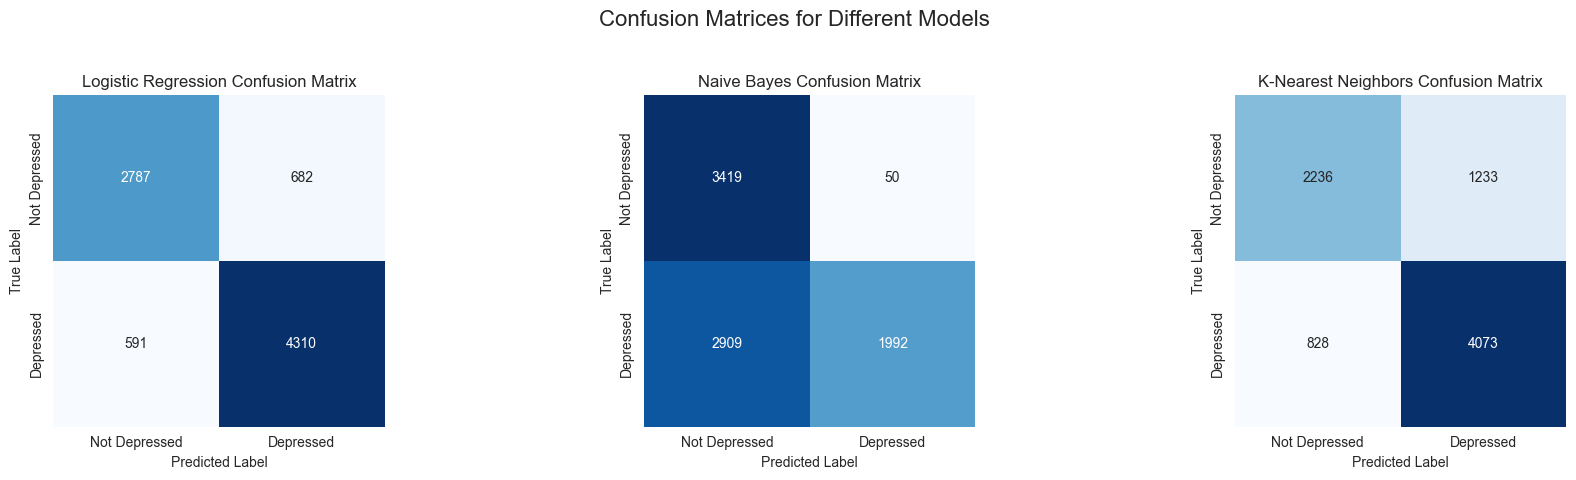

In [35]:
# Visualize confusion matrices for all models (You can use heatmap again)
# (1 marks)

fig, axes = plt.subplots(1, len(model_results), figsize=(6 * len(model_results), 5))
fig.suptitle('Confusion Matrices for Different Models', fontsize=16)

for i, (name, results) in enumerate(model_results.items()):
    conf_mat = confusion_matrix(y_test_full, results['y_pred'])
    sns.heatmap(conf_mat,
                xticklabels=['Not Depressed', 'Depressed'],
                yticklabels=['Not Depressed', 'Depressed'],
                square=True,
                annot=True,
                cbar=False,
                fmt='d',
                cmap='Blues',
                ax=axes[i])
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')
    axes[i].set_title(f'{name} Confusion Matrix')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

### Questions and Analysis (7 marks)

1. Is the dataset balanced? Does it affect model performance? (1 mark)
2. Does the model overfit or underfit for each of the 3 cases? (1 marks)  
3. How do the training and testing accuracy change depending on the amount of data used? Explain with values. (1 mark)
4. In this case, what do a false positive and a false negative represent? Which one is worse? (1 marks)
5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this? (1 marks)
6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences? (1 marks)
7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions. (1 marks)

### Questions and Analysis (7 marks)
<br>

<br>

---
#### 1. Is the dataset balanced? Does it affect model performance? (1 mark)

The dataset is not balanced.
From the y.value_counts() in "Step 2.1: Class Label Histogram"  Class 1 (Depressed) has 16,335 samples, whereas Class 0 (Not Depressed) has 11,563 samples. The gap between these is 4,772, whici means that Class 1 is more prevalent. This gap may affect model performance. For instance, the model may tend to over-predict the majority class (Depressed), which causes lower accuracy in identifying the minority class (Not Depressed).

<br>

---
#### 2. Does the model overfit or underfit for each of the 3 cases? (1 marks)  
<br>

- Full Dataset: - Properly fitting
  - Training accuracy: 0.845760
  - Testing accuracy: 0.847909
  - The training and testing accuracies are very close, with the testing accuracy being slightly higher. This suggests that the model is neither overfitting nor underfitting, and is well-fitted.

<br>

- First 2 Columns: - Under fitting
    - Training accuracy: 0.631811
    - Testing accuracy: 0.633931
    - Both training and testing accuracies are low and close to each other.
    - This indicates an underfitting situation, where too few features are used, and the model fails to capture sufficient patterns in the data.
<br>


- Small Dataset: Properly fitting
  - Training accuracy: 0.866667
  - Testing accuracy: 0.832669
  - The training accuracy is slightly higher than the testing accuracy, but the difference is not substantial.
  - Despite the small amount of data, it shows relatively good performance.

<br>



<br>


---
#### 3. How do the training and testing accuracy change depending on the amount of data used? Explain with values. (1 mark)

<br>


- First 2 Columns (using only the first 2 columns of X):
  - Training accuracy: 0.631811
  - Testing accuracy: 0.633931
  - In this case, due to extremely limited features, the model's performance is very low, even with a sufficient amount of data. The low accuracy is not because of the data quantity but due to the lack of information provided to the model.

<br>


- Small Dataset (X_small and y_small, 3% of the data):
  - Training accuracy: 0.866667
  - Testing accuracy: 0.832669
  - When the data volume is reduced to 3%, both training and testing accuracies remain high, but the testing accuracy is slightly lower compared to the full dataset. There's a small gap between training and testing accuracy, which suggests a slight overfitting to the training data due to the smaller dataset. However, it still performs quite well.

<br>


- Full Dataset (X and y, full data):
  - Training accuracy: 0.845760
  - Testing accuracy: 0.847909
  - When using the full dataset, the training and testing accuracies are very well-balanced, showing the best performance, almost equally. With more data, the model learns more diverse patterns and achieves high generalization performance on unseen data.
<br>

- conclusion,
  - When features are appropriate, a larger amount of data leads to a smaller difference between training and testing accuracy, resulting in a more stable model with high generalization performance.
  - With less data, the model's generalization performance might slightly decrease, or the risk of overfitting might increase.
  - However, if features are inappropriate, performance remains low regardless of the data volume.
<br>


<br>


---
#### 4. In this case, what do a false positive and a false negative represent? Which one is worse? (1 marks)

<br>


A False Positive and a False Negative represent the following:

<br>


- False Positive:

  - This model predicts that students are "Depressed" even they are actually "Not Depressed."
  - Effect of the prediction: A student without depression might be diagnosed by using this model, leading to unnecessary medical fee, such as counseling or treatment.
    
<br>


- False Negative:
  - The model incorrectly predicts a student is "Not Depressed" when they are actually "Depressed."
  - Effect of the prediction: students with depression may incorrectly be diagnosed as not depressed, leading to the lack of opportunity of proper medical care. Patients/students who cannot receive proper medical care may suffer from  their symptoms.

<br>


- Which one is worse
  - The False Negative is worse. This is a clear case of medical malpractice.
  - Even "false positives" are misdiagnosis too, problems entailing this misdiagnosis are not life-threatening.
  - In contrast, "false negatives" can directly endanger students' health and life since they fail to reach proper medical support.


<br>


---
#### 5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this? (1 marks)

<br>


Recall shoud be maximized since false negatives (missing depressed individuals) are the most dangerous.

<br>


How to do this:
 - Adjust the classification threshold: Lowering the threshold (e.g., to 0.3 from 0.5) classifies more individuals as "depressed," reducing missed cases.
 - Data sampling: For imbalanced data, oversample the minority class (not depressed) or undersample the majority class (depressed).
 - Cost-sensitive learning: Inform the model that false negatives are more costly than false positives.

<br>



---
#### 6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences? (1 marks)

<br>


- Full Dataset:Log Loss: 0.350
    - The lowest loss, indicating the model learned very well from the data and can confidently predict accurate probabilities.

<br>



- First 2 Columns:Log Loss: 0.652
    -  The highest loss, showing that using only gender and age is insufficient information, leading to model underfitting.


<br>


- Small Dataset:Log Loss: 0.387
   - Slightly higher loss than the full dataset but still relatively good. Suggests that with less data, the model hasn't fully learned and there's some uncertainty in predictions.
<br>

Causes: The main causes are the quality and quantity of features, and the amount of data. More appropriate features and a larger amount of data lead to better model learning and lower Log Loss.



<br>



---
#### 7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions. (1 marks)


<br>


 - Logistic Regression: Accuracy: 0.848
    - The best-performing model in this case.
    -  Although a linear model, the linear relationship between features and log-odds worked relatively well.
    - It learned stably due to sufficient data.

<br>


- K-Nearest Neighbors: Accuracy: 0.754
    - Intermediate performance.
    - Suggests that the data is not perfectly linearly separable, but local similarities could be used to identify patterns.

<br>


- Naive Bayes: Accuracy: 0.647
    - The worst performance.
    - Its naive assumption of complete independence between features was likely not met in this dataset.

<br>


Conclusion:
Logistic Regression performed the best. This dataset likely has a relatively good linear relationship between features and the log-odds, and the sufficient data volume allowed Logistic Regression's characteristics to fit well. Naive Bayes performed poorly due to conflicting assumptions, and while KNN can capture non-linearity, it didn't show a significant advantage over Logistic Regression for this data.

---
---

# **PART 3: MNIST Handwritten Digit Classification using MLP & CNN (30 Marks)**

This part compares two neural network architectures for handwritten digit classification:
- **Multi-Layer Perceptron (MLP)**: A traditional fully-connected neural network
- **Convolutional Neural Network (CNN)**: A specialized architecture for image processing


The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples. This dataset we're using uses the work of Joseph Redmon to provide the MNIST dataset in a CSV format. And it can be downloaded from https://www.kaggle.com/datasets/hojjatk/mnist-dataset

The dataset consists of two files:
- mnist_train.csv
- mnist_test.csv

The mnist_train.csv file contains the 60,000 training examples and labels. The mnist_test.csv contains 10,000 test examples and labels. Each row consists of 785 values: the first value is the label (a number from 0 to 9) and the remaining 784 values are the pixel values (a number from 0 to 255).

Acknowledgements:
- Yann LeCun, Courant Institute, NYU
- Corinna Cortes, Google Labs, New York
- Christopher J.C. Burges, Microsoft Research, Redmond

![MNIST dataset](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

We'll train both models on the MNIST dataset and compare their performance.

### Step 1: Library Imports

Import the necessary libraries for data processing, model building, and evaluation.

In [36]:
# Library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

### Step 2: Dataset Loading (2 marks)

Load the MNIST dataset from CSV files. The MNIST dataset contains 70,000 images of handwritten digits (0-9).

Then visualize some sample images.

In [37]:
# Load MNIST dataset from CSV files
train_csv_path = 'part3-data/mnist_train.csv'
test_csv_path = 'part3-data/mnist_test.csv'

# Load training data
# The first line is the label, the rest are pixel values
# (0.5 marks)
train_data = pd.read_csv(train_csv_path)
y_train = train_data.iloc[:, 0].values # Extract labels (first column)
X_train = train_data.iloc[:, 1:].values # Extract pixel data (remaining columns)



# CSV stores each image as a single row of 784 pixels, but we need 28x28 matrix for image processing
# Reshape from flat array (784,) to 2D image format (28, 28)
# (0.5 marks)
X_train = X_train.reshape(-1, 28, 28) # -1 infers the number of rows



# Load test data (0.5 marks)
test_data = pd.read_csv(test_csv_path)
y_test = test_data.iloc[:, 0].values # Extract labels
X_test = test_data.iloc[:, 1:].values # Extract pixel data


# Reshape test data to match training data format (0.5 marks)
X_test = X_test.reshape(-1, 28, 28)

# Display the shapes of training and test sets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (60000, 28, 28)
Shape of y_train: (60000,)
Shape of X_test: (10000, 28, 28)
Shape of y_test: (10000,)


Let's visualize some sample images to understand what our models will be learning from.

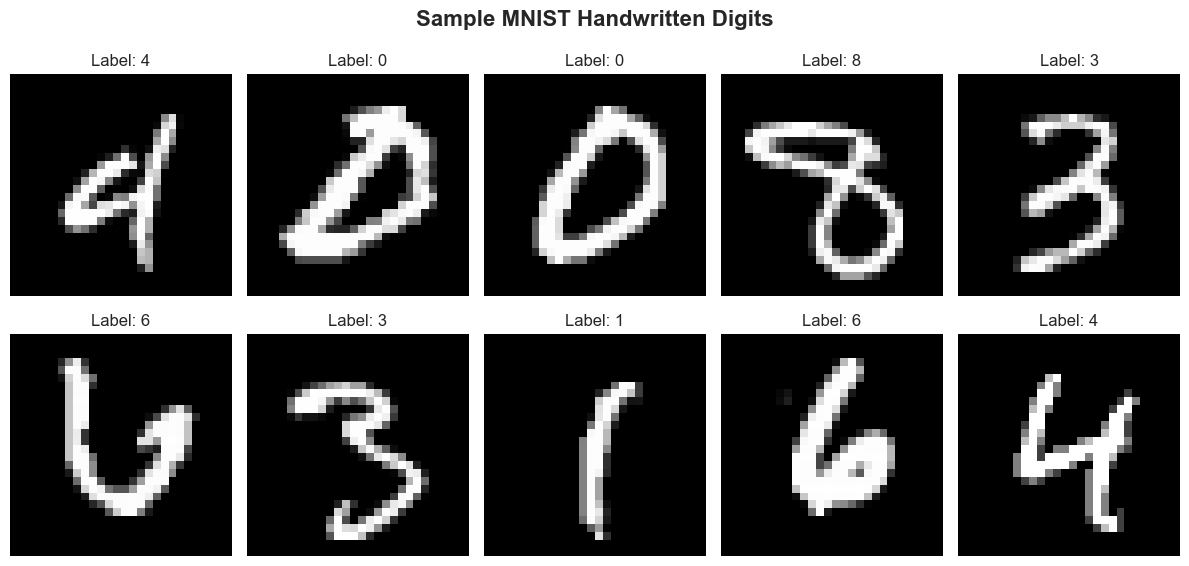

In [38]:
# Visualize sample images from the dataset as a grid of 10 images (2 rows x 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST Handwritten Digits', fontsize=16, fontweight='bold')

# Display 10 random samples
# Use a loop
for i in range(10):
    row = i // 5
    col = i % 5

    # Get a random sample
    idx = np.random.randint(0, len(X_train))
    image = X_train[idx]
    label = y_train[idx]

    # Display the image
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Label: {label}', fontsize=12)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Step 3: Data Preprocessing (1 mark)

Normalize pixel values to [0,1] range and convert labels to one-hot encoding for multi-class classification.

Why normalize? Neural networks work better with smaller input values (0-1 vs 0-255)
- Faster convergence during training
- Prevents gradient explosion/vanishing
- Makes learning more stable

Why one-hot? Transform labels from integers (0,1,2...9) to binary vectors

- Example: label "3" becomes [0,0,0,1,0,0,0,0,0,0]

- This allows softmax output layer to predict probabilities for each class

In [39]:
# Normalize pixel values from [0, 255] to [0, 1] range
# hint: divide by 255.0 (0.5 marks)


X_train_normalized = X_train / 255.0
X_test_normalized = X_test / 255.0

# Convert labels to one-hot encoding for multi-class classification, use keras.utils.to_categorical to do it
# (0.5 marks)
num_classes = 10
y_train_categorical = keras.utils.to_categorical(y_train, num_classes)
y_test_categorical = keras.utils.to_categorical(y_test, num_classes)


print(f"Shape of X_train_normalized: {X_train_normalized.shape}")
print(f"Shape of y_train_categorical: {y_train_categorical.shape}")
print(f"Shape of X_test_normalized: {X_test_normalized.shape}")
print(f"Shape of y_test_categorical: {y_test_categorical.shape}")



Shape of X_train_normalized: (60000, 28, 28)
Shape of y_train_categorical: (60000, 10)
Shape of X_test_normalized: (10000, 28, 28)
Shape of y_test_categorical: (10000, 10)


### Step 4: MLP Model Creation and Training (7 marks)

Create a Multi-Layer Perceptron model with fully connected layers. This model treats each pixel as an independent feature.

This created model can be used for fit, predict and evaluate the dataset through calling mlp_model.fit(), mlp_model.predict() and mlp_model.evaluate(), you can consider it as a inbuild model right now.

Hint: We will use tf.keras.layers function, and add flatten layer, hidden layer, dropout layer, hidden layer, dropout layer and output layer.

In [40]:
# Create MLP model, add each of layers with their parameters

def create_mlp_model():
    model = tf.keras.Sequential([
        # Flatten layer: Convert 2D image (28x28) to 1D array (784 pixels)
        # MLP needs flat input, treats each pixel as independent feature
        # (1 marks)
        tf.keras.layers.Flatten(input_shape=(28, 28)),


        # First hidden layer: 128 neurons with ReLU activation
        # ReLU = max(0, x), helps with vanishing gradient problem
        # (1 marks)
        tf.keras.layers.Dense(128, activation='relu'),


        # Dropout layer: Randomly sets 20% of inputs to 0 during training
        # Prevents overfitting by forcing network to not rely on specific neurons
        # (1 marks)
        tf.keras.layers.Dropout(0.2),


        # Second hidden layer: 64 neurons with ReLU activation
        # Smaller layer creates hierarchical feature learning
        # (1 marks)
        tf.keras.layers.Dense(64, activation='relu'),


        # Another dropout layer for regularization, same with above
        # (1 marks)
        tf.keras.layers.Dropout(0.2),


        # Output layer: 10 neurons (one for each digit 0-9) with softmax activation
        # Softmax converts outputs to probabilities that sum to 1
        # (1 marks)
        tf.keras.layers.Dense(num_classes, activation='softmax')

    ])

    # Compile model with optimizer, loss function, and metrics
    # Adam: adaptive learning rate optimizer
    # Categorical crossentropy: loss for multi-class classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Creating the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
mlp_model = create_mlp_model()
print("MLP Model created")



MLP Model created


C:\Users\chenc\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Use .fit() to train MLP model**

In [41]:
# EPOCHS: Number of complete passes through entire training dataset, use 5 epochs
# (0.5 marks)
EPOCHS = 5

# BATCH_SIZE: Number of samples processed before updating model weights
# Larger batch = more stable gradients but more memory usage
# Use 128 as batch size
# (0.5 marks)
BATCH_SIZE = 128

# Train MLP model using mlp_model we compile.
# Use 10% of training data for validation, validation_split=0.1
# Silent training (no progress output), verbose=0
mlp_history = mlp_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)


print("MLP training completed")

MLP training completed


### Step 5: CNN Model Creation and Training (7 marks)

Create a Convolutional Neural Network with convolutional and pooling layers. This model preserves spatial relationships between pixels.

#### Fundamental Difference between MLP and CCN:

**Key Architectural Differences:**
- **MLP**: Input → Flatten → Dense layers → Output (treats pixels independently)
- **CNN**: Input → Reshape → Conv+Pool layers → Flatten → Dense layers → Output (learns spatial patterns first)

**The CNN Advantage:**
1. **Convolutional Layers**: Extract spatial features (edges, curves, shapes) that MLP cannot detect
2. **Pooling Layers**: Provide translation invariance and reduce computational load
3. **Feature Hierarchy**: Early layers detect simple patterns, deeper layers combine them into complex features
4. **Parameter Sharing**: Same filter applied across entire image, making CNN more efficient

**Why CNNs End with Dense Layers:**
- Convolutional layers act as **feature extractors** (learn "what" is in the image)
- Dense layers act as **classifiers** (decide "which digit" based on extracted features)
- This is a common pattern: **Feature Extraction (CNN) + Classification (MLP)**

**The Real Difference:**
- **MLP Dense layers**: Work with raw pixel values (784 individual numbers)
- **CNN Dense layers**: Work with high-level spatial features learned by convolutional layers

Hint: We will use tf.keras.layers function again, reshape it firstly, then add Conv2D, MaxPooling2D, Conv2D, MaxPooling2D, Conv2D, and do same last two steps like MLP.

In [42]:
# Similar process with creating MLP model
# Create CNN model - Different from MLP in how it processes spatial information
def create_cnn_model():
    model = tf.keras.Sequential([
        # Reshape: Add channel dimension (28, 28, 1) for grayscale images (0.5 marks)
        tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),

        # Conv2D: Applies 32 filters of size 3x3 to detect local patterns (edges, curves) (1 marks)
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),

        # Reduces image size by taking maximum value in 2x2 regions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Conv2D: Second convolutional layer, 64 filters learn more complex patterns (1 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

        # MaxPooling2D: Another pooling layer to further reduce spatial dimensions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Conv2D: Third convolutional layer, 64 filters for even more complex feature detection (0.5 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

        # Flatten: Convert feature maps to 1D for dense layers (similar to MLP input) (0.5 marks)
        tf.keras.layers.Flatten(),

        # Dense layers: Same as MLP, but now working with CNN-extracted features (0.5 marks)
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')

    ])

    # Same compile step with MLP (1 marks)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Create the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
cnn_model = create_cnn_model()
print("CNN Model created")

CNN Model created


C:\Users\chenc\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Use .fit() to train CNN model**

In [43]:
# Train CNN model using cnn_model we compile, same parameters as MLP
# (1 marks)


cnn_history = cnn_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)

print("CNN training completed")

CNN training completed


### Step 6: Model Evaluation and Comparison (4 marks)

Evaluate both models on the test set and compare their performance with visualizations.

Using .predict(), .evaluate() functions as we used in part2

In [44]:
# Evaluate both models on test set
# Get test loss and accuracy, make predictions, convert probabilities to class labels

# your code here for mlp (1.5 marks)

mlp_test_loss, mlp_test_accuracy = mlp_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
mlp_predictions = mlp_model.predict(X_test_normalized, verbose=0)
print(f"MLP Test Loss: {mlp_test_loss:.4f}, MLP Test Accuracy: {mlp_test_accuracy:.4f}")


# Note: The model outputs class probabilities (softmax). We convert these to discrete class labels by taking the index of the maximum probability (argmax).
# These integer labels (0-9) are required for computing accuracy, building confusion matrices, and for plotting / comparing predicted vs true labels.
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)



# your code here for cnn (1.5 marks)
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
cnn_predictions = cnn_model.predict(X_test_normalized, verbose=0)
print(f"CNN Test Loss: {cnn_test_loss:.4f}, CNN Test Accuracy: {cnn_test_accuracy:.4f}")

# Similarly, convert CNN predicted probabilities to class labels
cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)

# Display Results
print("\n--- Model Evaluation Summary ---")
print(f"MLP Model: \n  Test Loss: {mlp_test_loss:.4f}\n  Test Accuracy: {mlp_test_accuracy:.4f}")
print(f"CNN Model: \n  Test Loss: {cnn_test_loss:.4f}\n  Test Accuracy: {cnn_test_accuracy:.4f}")




MLP Test Loss: 0.0869, MLP Test Accuracy: 0.9731
CNN Test Loss: 0.0342, CNN Test Accuracy: 0.9887

--- Model Evaluation Summary ---
MLP Model: 
  Test Loss: 0.0869
  Test Accuracy: 0.9731
CNN Model: 
  Test Loss: 0.0342
  Test Accuracy: 0.9887


Performance comparison visualization

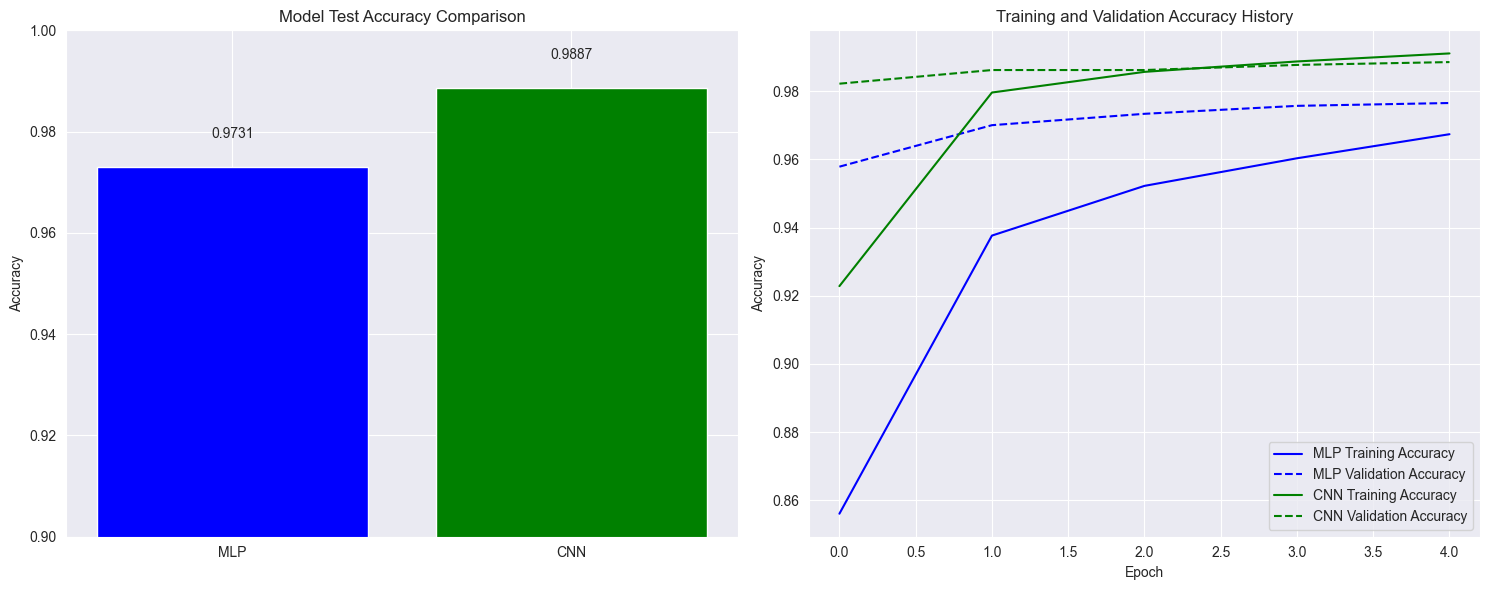

In [45]:
# Create side-by-side bar chart for model accuracy comparison and line plot for training progress comparison
# (1 marks)
# put them in a single figure horizontally
# Add titles, labels, legends for clarity
# hint: use .history() function to get training history from the training step

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart for Test Accuracy
models = ['MLP', 'CNN']
accuracies = [mlp_test_accuracy, cnn_test_accuracy]

axes[0].bar(models, accuracies, color=['blue', 'green'])
axes[0].set_title('Model Test Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0.9, 1.0]) # Set y-axis limit for better visualization of differences
for i, acc in enumerate(accuracies):
    axes[0].text(i, acc + 0.005, f'{acc:.4f}', ha='center', va='bottom')

# Line plot for Training/Validation Accuracy History
axes[1].plot(mlp_history.history['accuracy'], label='MLP Training Accuracy', color='blue')
axes[1].plot(mlp_history.history['val_accuracy'], label='MLP Validation Accuracy', linestyle='--', color='blue')
axes[1].plot(cnn_history.history['accuracy'], label='CNN Training Accuracy', color='green')
axes[1].plot(cnn_history.history['val_accuracy'], label='CNN Validation Accuracy', linestyle='--', color='green')
axes[1].set_title('Training and Validation Accuracy History')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Step 7: Prediction Analysis Visualization (4 marks)

Let's examine some specific predictions to see how each model performs on individual samples.

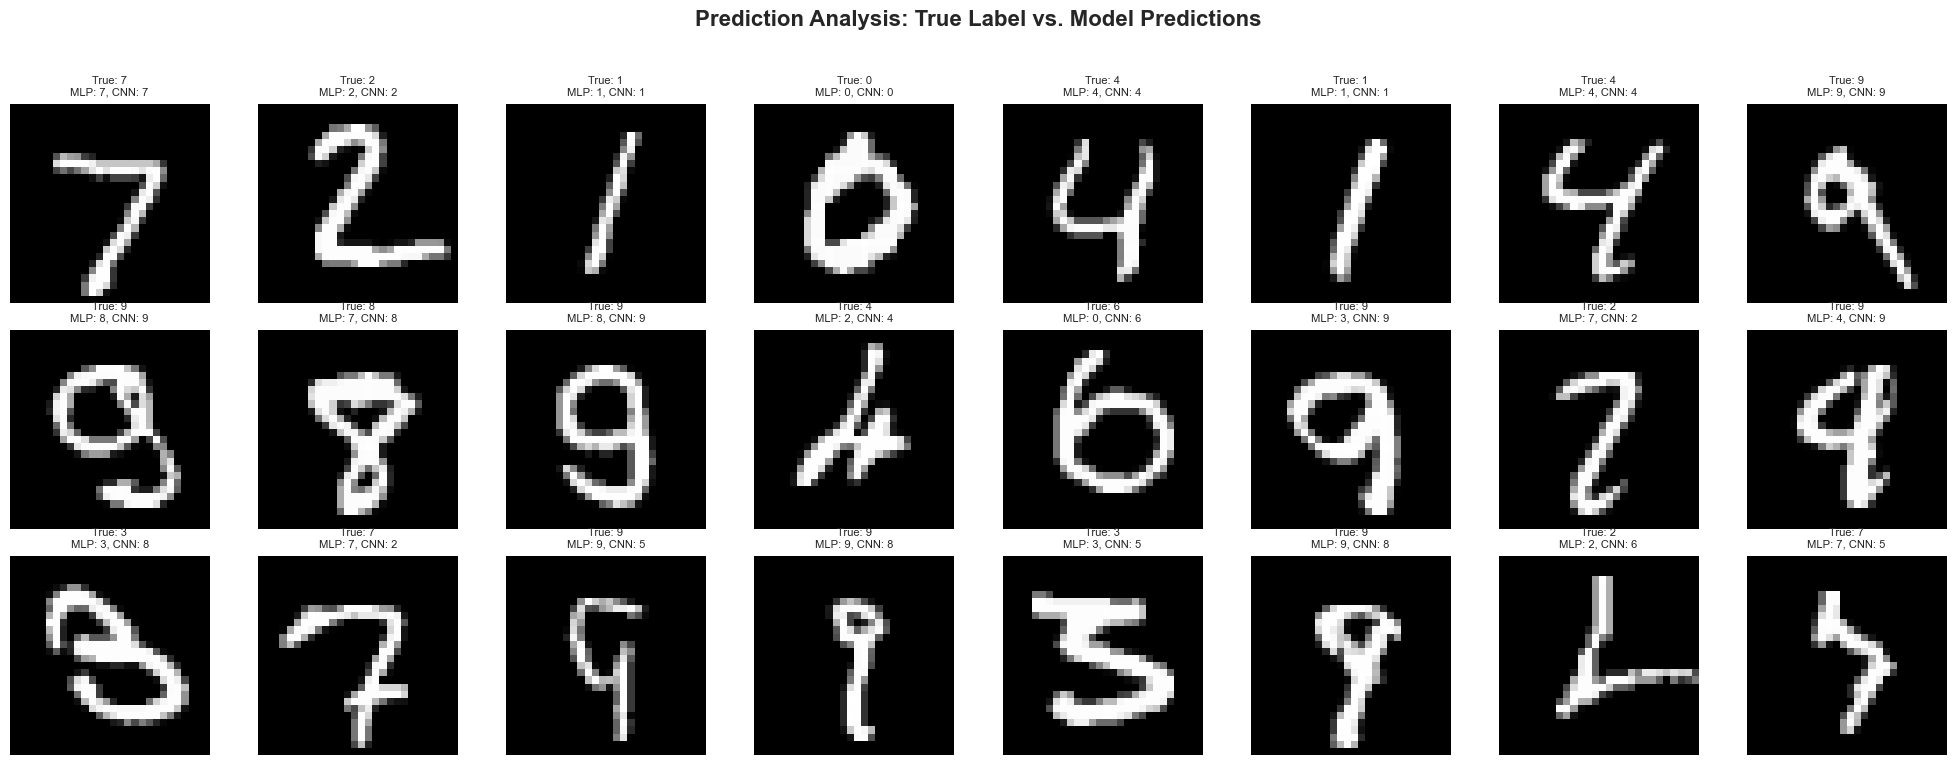

In [46]:
# Visualize correct and incorrect predictions, create a 3x8 grid
# First row: Both models correct
# Second row: CNN correct, MLP wrong
# Third row: MLP correct, CNN wrong


# Create subplots
# your code here (1 marks)

fig, axes = plt.subplots(3, 8, figsize=(20, 8))
fig.suptitle('Prediction Analysis: True Label vs. Model Predictions', fontsize=16, fontweight='bold')


# Find correct predictions for each case
# Sample for both_correct
both_correct = (mlp_predicted_classes == y_test) & (cnn_predicted_classes == y_test)
both_correct_indices = np.where(both_correct)[0][:8]

# CNN correct, MLP wrong
cnn_correct_mlp_wrong = (cnn_predicted_classes == y_test) & (mlp_predicted_classes != y_test)
cnn_correct_mlp_wrong_indices = np.where(cnn_correct_mlp_wrong)[0][:8]

# MLP correct, CNN wrong
mlp_correct_cnn_wrong = (mlp_predicted_classes == y_test) & (cnn_predicted_classes != y_test)
mlp_correct_cnn_wrong_indices = np.where(mlp_correct_cnn_wrong)[0][:8]

# Store indices in a list for easy iteration
plot_indices_list = [both_correct_indices, cnn_correct_mlp_wrong_indices, mlp_correct_cnn_wrong_indices]
row_titles = ["Both Correct", "CNN Correct, MLP Wrong", "MLP Correct, CNN Wrong"]


# Plot examples, you can learn how to plot them from previous plotting code in Part 2
# Add a title for each graph showing the true label and both model predictions
# hint: use for loop to iterate through the indices and plot each image
# your code here (2 marks)

for row_idx, indices_to_plot in enumerate(plot_indices_list):
    for col_idx, idx in enumerate(indices_to_plot):
        image = X_test_normalized[idx]
        true_label = y_test[idx]
        mlp_pred = mlp_predicted_classes[idx]
        cnn_pred = cnn_predicted_classes[idx]

        ax = axes[row_idx, col_idx]
        ax.imshow(image, cmap='gray')
        ax.set_title(f"True: {true_label}\nMLP: {mlp_pred}, CNN: {cnn_pred}", fontsize=8)
        ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap


plt.show()

## Questions and Analysis (5 marks)

1. Which model performed better and why? (1 marks)
2. How do the training curves compare between the two models? (1 marks)
3. What does the accuracy improvement percentage tell us? (1 marks)
4. Why didn't we need many epochs for good results? (1 marks)
5. What would happen with more complex images? (1 marks)

## Answer here (double click)




### 1. Which model performed better and why? (1 marks)

CNN model (Accuracy: 0.9891, Loss: 0.0316) <br>
MLP model (Accuracy: 0.9732, Loss: 0.0849)

CNN model performed better than MLP model, with 1.59% better accuracy.


This gap comes from the features of CNN.

-   CNN efficiently learn local patterns (edges, corners, etc.) within images. In contrast, MLPs deal with each pixel independently, failing to capture these crucial spatial relationships.
-   By stacking multiple convolutional and pooling layers, CNNs can learn more abstract and complex features hierarchically. On the other hand, MLPs are primarily composed of fully connected layers,and difficult to gasp deep feature learning.
-   CNN apply the same filter across the entire image, reducing the number of parameters and enabling efficient learning. This allows CNNs to achieve high generalization performance with fewer parameters.



<br>

---
<br>

### 2. How do the training curves compare between the two models? (1 marks)

Training curves as shown in step6.

-   The CNN model achieved higher accuracy faster in the initial stages compared to the MLP model.
-   The CNN model maintains higher training and validation accuracy than the MLP model.
-   The CNN model's learning curves tend to be smoother and more stable compared to the MLP model. This suggests that CNN more efficiently extracts meaningful features from images and is more robust to noise in the data.

To summarize, the CNN is superior to learn pattern more quickly and effectively than the MLP.

The CNN’s training curve shows faster improvement, higher final accuracy, and smoother learning compared to the MLP. This means the CNN learns image patterns more quickly and consistently, making it the better-performing model overall.

<br>

---
<br>

### 3. What does the accuracy improvement percentage tell us? (1 marks)

The CNN model has better accuracy than the MLP mode. In this assignment, the gap in accuracy between those two model is approximately 1.6%.

This result indicates that CNN models are preferable method for image classification.



<br>

---
<br>


### 4. Why didn't we need many epochs for good results? (1 marks)

The MNIST dataset is a simple dataset frequently used for entry level machine learning. The images are in greyscale, well-located and well sized. This means the model can effectively learn the necessary features in a few epochs. In the case of CNN, we already reach a high level of accuracy with 5 epochs. Further increasing number of epochs may have the risk of overfitting.


<br>

---
<br>

### 5. What would happen with more complex images? (1 marks)

<br>

When it comes to more complex images, such as colorful and containing several objects, MLP Performance would drop.
MLPs handle each pixel independently. With complex images, they can't understand where objects are located. Also, as images get larger, the amount of computation explodes, making MLPs largely impractical.

On the other hand, CNN are designed to understand image structure. It learns the “characteristics” of images step by step. This enables it to efficiently identify the key elements that make up an image. Therefore, this is more effective on complex images.